In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import random

In [3]:
DATASET_PATH = 'data'

# Check if the dataset path is valid
if not os.path.exists(DATASET_PATH) or not os.path.isdir(DATASET_PATH):
    print(f"Error: The provided dataset path does not exist or is not a directory.")
else:
    # Get all image filenames
    image_files = [f for f in os.listdir(DATASET_PATH) if f.endswith('.png')]
    num_samples = len(image_files)
    print(f"Total number of samples: {num_samples}")

    # Get dimensions and mode from the first image
    if num_samples > 0:
        with Image.open(os.path.join(DATASET_PATH, image_files[0])) as img:
            width, height = img.size
            mode = img.mode
        print(f"Image dimensions (Width x Height): {width}x{height}")
        print(f"Image mode: {mode} ({'Color' if mode == 'RGB' else 'Grayscale'})")

Total number of samples: 1040
Image dimensions (Width x Height): 200x50
Image mode: RGBA (Grayscale)


Number of unique characters found: 19


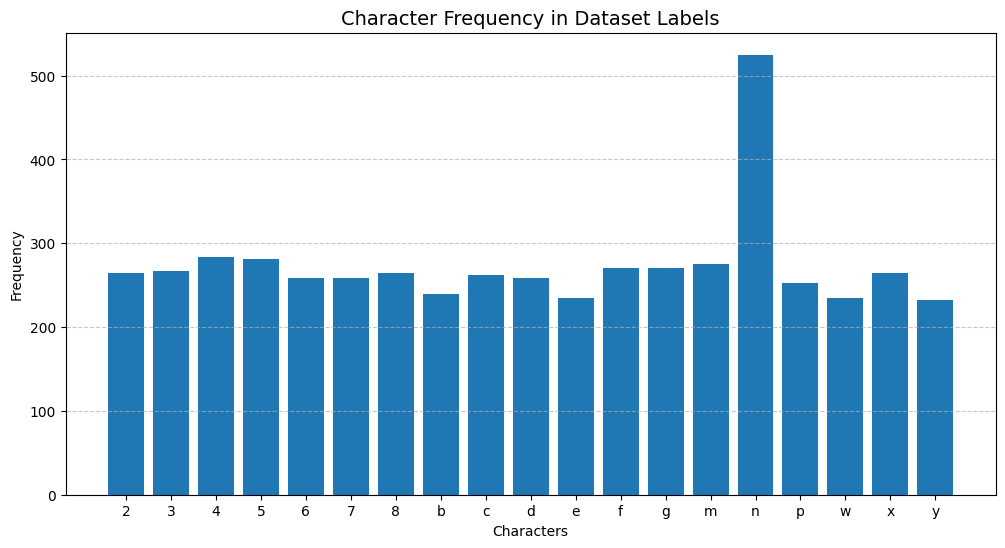

In [4]:
all_chars = ""
for filename in image_files:
    # The label is the filename without the '.png' extension
    label = os.path.splitext(filename)[0]
    all_chars += label

char_counts = Counter(all_chars)
print(f"Number of unique characters found: {len(char_counts)}")

# Plotting character frequency
plt.figure(figsize=(12, 6))
sorted_chars = sorted(char_counts.items())
chars, counts = zip(*sorted_chars)
plt.bar(chars, counts)
plt.title('Character Frequency in Dataset Labels', fontsize=14)
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

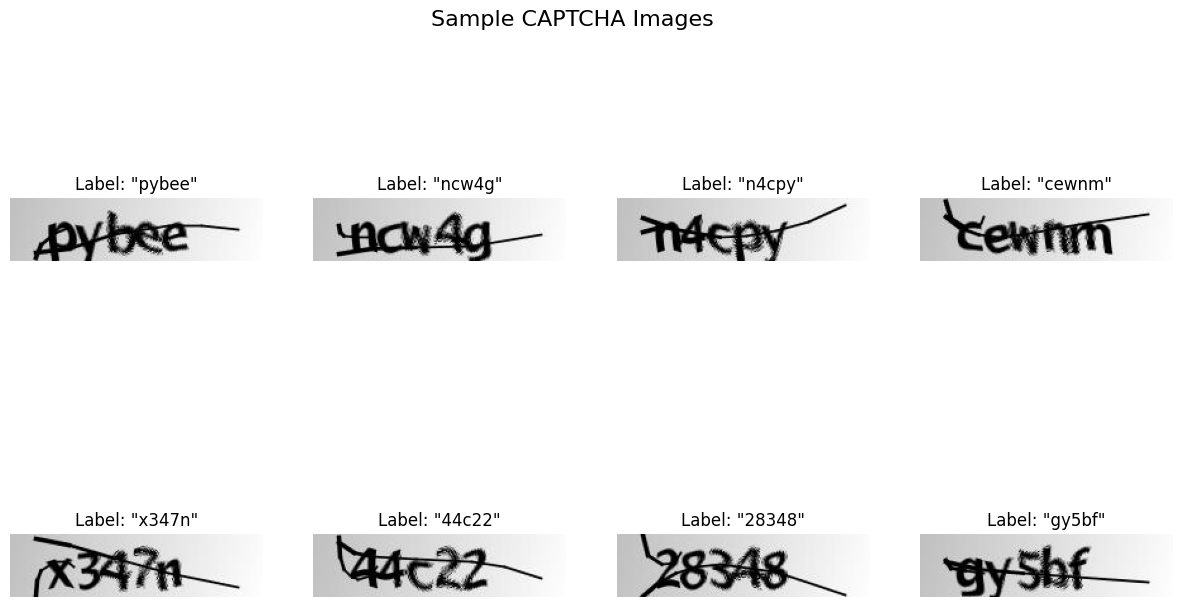

In [5]:
plt.figure(figsize=(15, 8))

# Select 8 random images to display
sample_images = random.sample(image_files, min(8, num_samples))

for i, filename in enumerate(sample_images):
    label = os.path.splitext(filename)[0]
    image_path = os.path.join(DATASET_PATH, filename)
    with Image.open(image_path) as img:
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f'Label: "{label}"')
        plt.axis('off') # Hide axes

plt.suptitle('Sample CAPTCHA Images', fontsize=16)
plt.show()

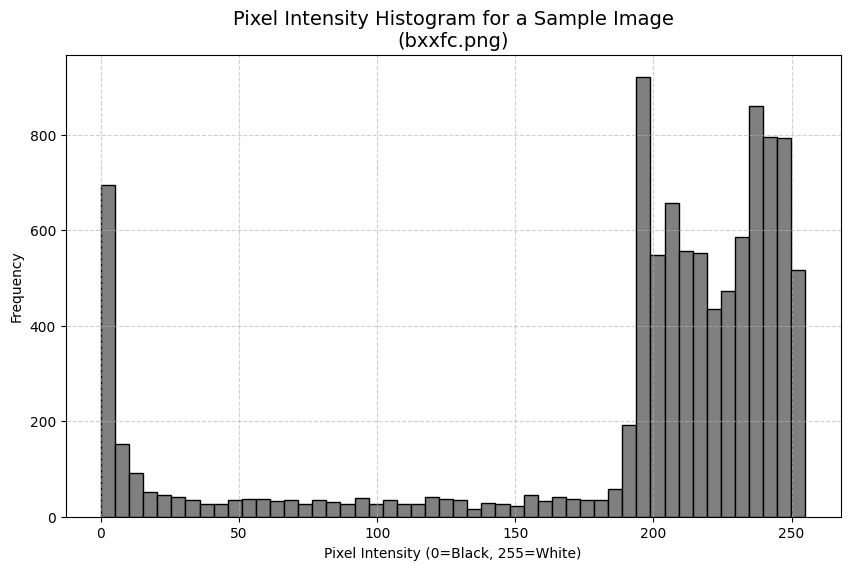

In [6]:
# Load one random image and convert to grayscale for analysis
sample_image_path = os.path.join(DATASET_PATH, random.choice(image_files))
with Image.open(sample_image_path).convert('L') as img: # 'L' mode is grayscale
    pixel_values = np.array(img).flatten()

    # Plotting the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(pixel_values, bins=50, color='gray', edgecolor='black')
    plt.title(f'Pixel Intensity Histogram for a Sample Image\n({os.path.basename(sample_image_path)})', fontsize=14)
    plt.xlabel('Pixel Intensity (0=Black, 255=White)')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()